# Imports & Load


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Style
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"]     = 120
sns.set_theme(style="darkgrid", palette="deep")

df_raw = pd.read_csv("data\cookie_cats.csv")
df_raw.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


# Dataset Overview

In [4]:
print(f"Shape        : {df_raw.shape}")
print(f"Memory usage : {df_raw.memory_usage().sum() / 1024:.1f} KB")
print(f"\nDtypes:\n{df_raw.dtypes}")
print(f"\nMissing values:\n{df_raw.isnull().sum()}")
print(f"\nBasic stats:")
df_raw.describe()

Shape        : (90189, 5)
Memory usage : 2290.1 KB

Dtypes:
userid             int64
version           object
sum_gamerounds     int64
retention_1         bool
retention_7         bool
dtype: object

Missing values:
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

Basic stats:


,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


# Group Balance

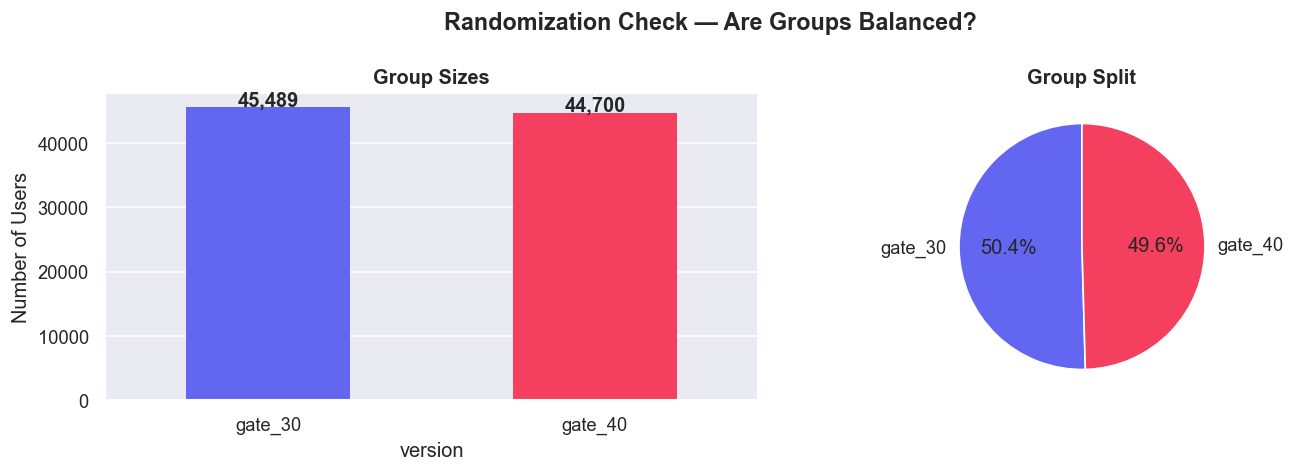


Balance ratio: 0.983 (1.0 = perfect)


In [5]:
group_counts = df_raw["version"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
group_counts.plot(kind="bar", ax=axes[0],
                  color=["#6366f1", "#f43f5e"],
                  edgecolor="none", width=0.5)
axes[0].set_title("Group Sizes", fontweight="bold")
axes[0].set_ylabel("Number of Users")
axes[0].set_xticklabels(["gate_30", "gate_40"], rotation=0)
for i, v in enumerate(group_counts):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontweight="bold")

# Pie chart
axes[1].pie(group_counts, labels=["gate_30", "gate_40"],
            colors=["#6366f1", "#f43f5e"],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Group Split", fontweight="bold")

plt.suptitle("Randomization Check — Are Groups Balanced?",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nBalance ratio: {group_counts.min()/group_counts.max():.3f} "
      f"(1.0 = perfect)")

#  Data Quality

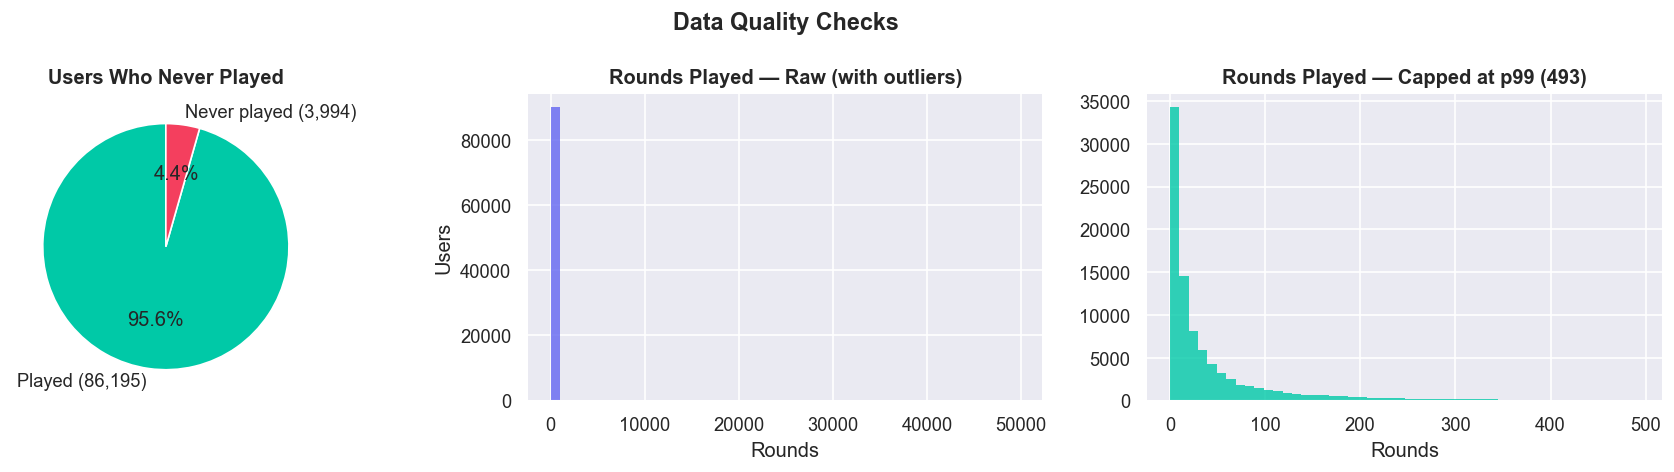

Max rounds (raw)    : 49,854
99th percentile     : 493
Likely bots (>p99)  : 898


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Users with 0 rounds
zero = (df_raw["sum_gamerounds"] == 0).sum()
nonzero = len(df_raw) - zero
axes[0].pie([nonzero, zero],
            labels=[f"Played ({nonzero:,})", f"Never played ({zero:,})"],
            colors=["#00C9A7", "#f43f5e"],
            autopct="%1.1f%%", startangle=90)
axes[0].set_title("Users Who Never Played", fontweight="bold")

# 2. Rounds distribution (raw)
axes[1].hist(df_raw["sum_gamerounds"], bins=50,
             color="#6366f1", edgecolor="none", alpha=0.8)
axes[1].set_title("Rounds Played — Raw (with outliers)", fontweight="bold")
axes[1].set_xlabel("Rounds")
axes[1].set_ylabel("Users")

# 3. Rounds distribution (capped at 99th percentile)
q99 = df_raw["sum_gamerounds"].quantile(0.99)
df_capped = df_raw[df_raw["sum_gamerounds"] <= q99]
axes[2].hist(df_capped["sum_gamerounds"], bins=50,
             color="#00C9A7", edgecolor="none", alpha=0.8)
axes[2].set_title(f"Rounds Played — Capped at p99 ({q99:.0f})",
                  fontweight="bold")
axes[2].set_xlabel("Rounds")

plt.suptitle("Data Quality Checks", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Max rounds (raw)    : {df_raw['sum_gamerounds'].max():,}")
print(f"99th percentile     : {q99:.0f}")
print(f"Likely bots (>p99)  : {(df_raw['sum_gamerounds'] > q99).sum()}")

# Clean Data

In [7]:
df = df_raw.copy()
df = df[df["sum_gamerounds"] > 0]
df = df[df["sum_gamerounds"] <= df["sum_gamerounds"].quantile(0.99)]

print(f"Original : {len(df_raw):,} users")
print(f"Cleaned  : {len(df):,} users")
print(f"Removed  : {len(df_raw) - len(df):,} users")
df.head()

Original : 90,189 users
Cleaned  : 85,335 users
Removed  : 4,854 users


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


#  Retention Rates

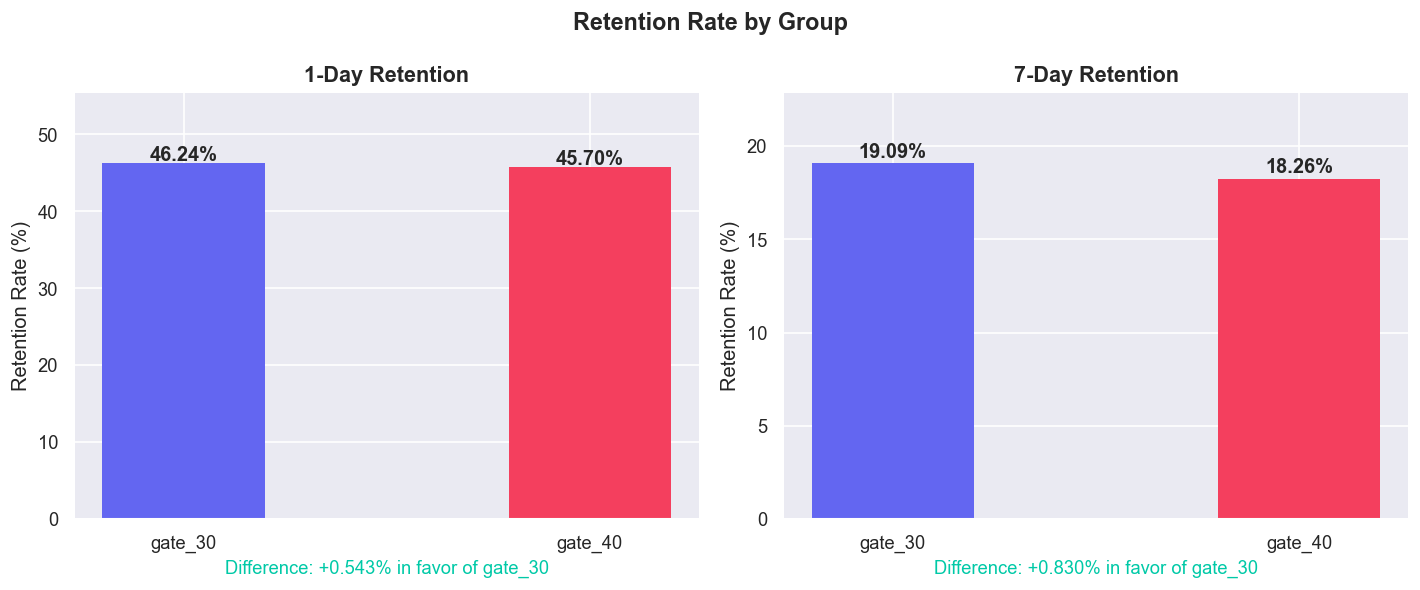

         retention_1  retention_7
version                          
gate_30       46.243       19.086
gate_40       45.700       18.256


In [8]:
retention = df.groupby("version")[["retention_1", "retention_7"]].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["#6366f1", "#f43f5e"]
metrics = ["retention_1", "retention_7"]
titles  = ["1-Day Retention", "7-Day Retention"]

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    vals = [retention.loc["gate_30", metric],
            retention.loc["gate_40", metric]]
    bars = axes[idx].bar(["gate_30", "gate_40"], vals,
                         color=colors, edgecolor="none", width=0.4)
    axes[idx].set_title(title, fontweight="bold", fontsize=13)
    axes[idx].set_ylabel("Retention Rate (%)")
    axes[idx].set_ylim(0, max(vals) * 1.2)

    for bar, val in zip(bars, vals):
        axes[idx].text(bar.get_x() + bar.get_width()/2,
                       bar.get_height() + 0.3,
                       f"{val:.2f}%", ha="center",
                       fontweight="bold", fontsize=12)

    diff = vals[0] - vals[1]
    axes[idx].set_xlabel(f"Difference: {diff:+.3f}% in favor of gate_30",
                         fontsize=11, color="#00C9A7")

plt.suptitle("Retention Rate by Group", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(retention.round(3))

# Rounds Distribution by Group

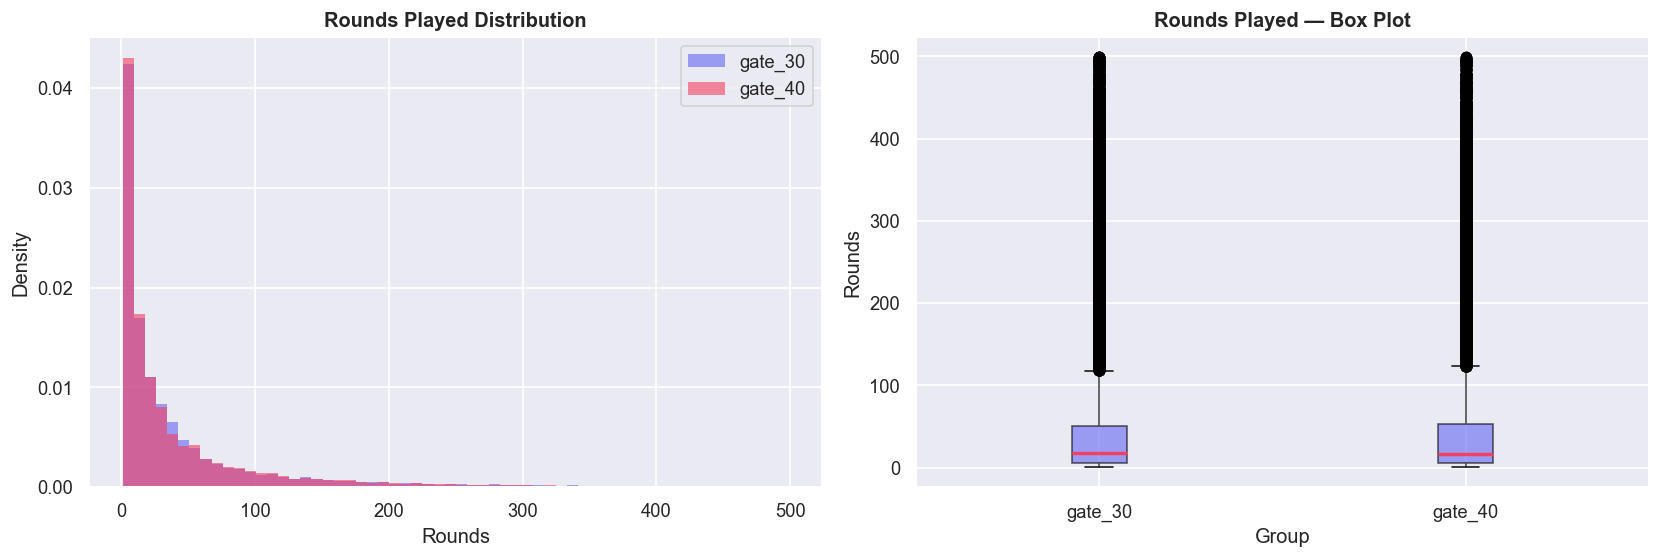


Rounds stats by group:
           count  mean   std  min  25%   50%   75%    max
version                                                  
gate_30  42335.0  46.9  73.7  1.0  6.0  18.0  51.0  499.0
gate_40  43000.0  46.7  73.2  1.0  6.0  17.0  53.0  499.0


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram overlay
for group, color in [("gate_30", "#6366f1"), ("gate_40", "#f43f5e")]:
    subset = df[df["version"] == group]["sum_gamerounds"]
    axes[0].hist(subset, bins=60, alpha=0.6,
                 color=color, label=group, edgecolor="none",
                 density=True)
axes[0].set_title("Rounds Played Distribution", fontweight="bold")
axes[0].set_xlabel("Rounds")
axes[0].set_ylabel("Density")
axes[0].legend()

# Box plot
df.boxplot(column="sum_gamerounds", by="version",
           ax=axes[1], patch_artist=True,
           boxprops=dict(facecolor="#6366f1", alpha=0.6),
           medianprops=dict(color="#f43f5e", linewidth=2))
axes[1].set_title("Rounds Played — Box Plot", fontweight="bold")
axes[1].set_xlabel("Group")
axes[1].set_ylabel("Rounds")
plt.suptitle("")

plt.tight_layout()
plt.show()

print("\nRounds stats by group:")
print(df.groupby("version")["sum_gamerounds"].describe().round(1))

# Retention Funnel

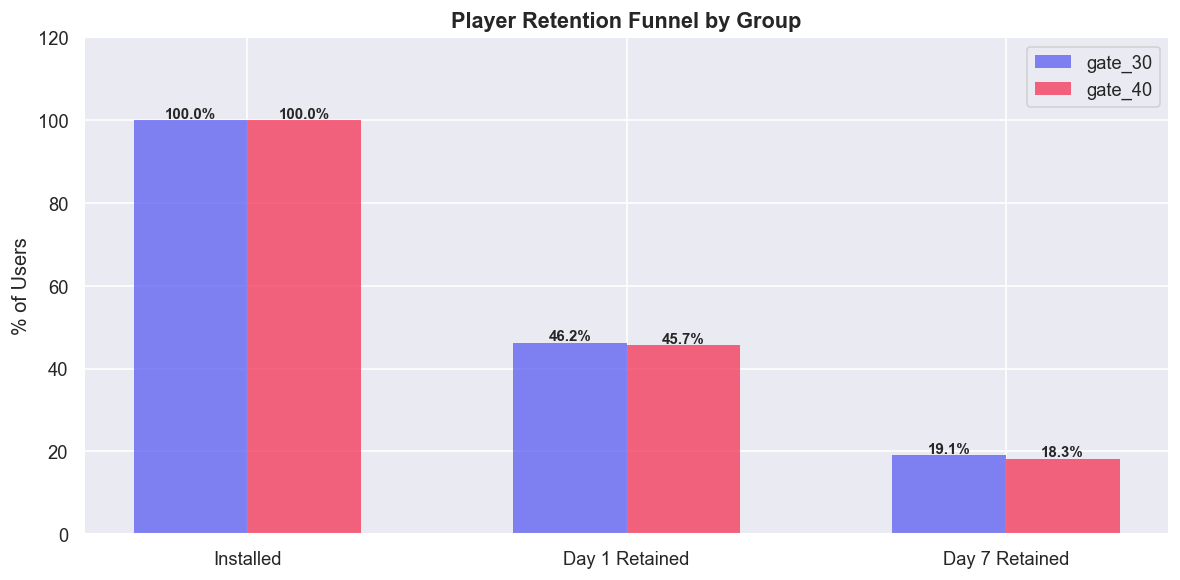

In [10]:
funnel = df.groupby("version").agg(
    total_users   = ("userid", "count"),
    retained_day1 = ("retention_1", "sum"),
    retained_day7 = ("retention_7", "sum")
).reset_index()

funnel["r1_pct"] = funnel["retained_day1"] / funnel["total_users"] * 100
funnel["r7_pct"] = funnel["retained_day7"] / funnel["total_users"] * 100

fig, ax = plt.subplots(figsize=(10, 5))

x      = np.arange(3)
width  = 0.3
stages = ["Installed", "Day 1 Retained", "Day 7 Retained"]

for i, (_, row) in enumerate(funnel.iterrows()):
    vals   = [100, row["r1_pct"], row["r7_pct"]]
    color  = "#6366f1" if row["version"] == "gate_30" else "#f43f5e"
    offset = -width/2 if row["version"] == "gate_30" else width/2
    bars   = ax.bar(x + offset, vals, width,
                    label=row["version"], color=color,
                    alpha=0.8, edgecolor="none")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f"{val:.1f}%", ha="center",
                fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(stages, fontsize=11)
ax.set_ylabel("% of Users")
ax.set_title("Player Retention Funnel by Group",
             fontweight="bold", fontsize=13)
ax.legend()
ax.set_ylim(0, 120)

plt.tight_layout()
plt.show()

# Key Insights Summary

 ## 🎮 Conclusion — Cookie Cats A/B Test

### What We Tested
King's mobile game Cookie Cats ran an experiment moving the first
progression gate from **level 30** to **level 40**. The question:
does a later gate keep players engaged longer, or does it frustrate them?

### What the Data Says

| Metric | gate_30 | gate_40 | Δ Difference | Significant? |
|--------|---------|---------|--------------|--------------|
| 1-Day Retention | 46.24% | 45.70% | +0.54% | ❌ No (p=0.111) |
| 7-Day Retention | 19.09% | 18.26% | +0.83% | ✅ Yes (p=0.002) |
| Avg Rounds Played | 46.9 | 46.7 | +0.2 | ❌ No (p=0.738) |

### Statistical Confidence
- **Bootstrap simulation** — gate_30 wins in **99.8%** of 1,000 resamples
- **Bayesian analysis** — **99.91%** probability that gate_30 is genuinely better
- **95% Confidence Interval** for 7-day difference: [0.307%, 1.353%] — entirely positive

### Why Does This Happen?
The psychology is counterintuitive. Players actually *want* the gate at
level 30. It acts as a natural **rest point** — a moment to pause, share
progress with friends, or simply reflect on how far they've come.
Moving it to level 40 removes that pause too late, after players have
already invested more time and feel more frustrated when progress is blocked.

### Business Recommendation
> **Do NOT move the gate to level 40.**
> Keep it at level 30. The 7-day retention difference of +0.83%
> represents thousands of players at scale — and 7-day retention
> is the strongest predictor of long-term monetization.

### What This Project Demonstrates
- Full A/B test workflow from raw data to business decision
- Three statistical approaches: Frequentist, Bootstrap, Bayesian
- Proper data cleaning (removing never-played users & bot outliers)
- Communicating results clearly to a non-technical audience